<a href="https://colab.research.google.com/github/gnbreddy/AI-powered-Estimation-of-crop-water-footprints-using-remote-sensing/blob/main/AI%20powered%20Estimation%20of%20crop%20water%20footprints%20using%20remote%20sensing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Earth Engine Initialized Successfully!
Extracted 813 sample points.


,ET,Precipitation,Tmax,Tmin,GWF,BWF
0,847.5,3141.549664,304.087051,298.322764,847.5,0.0
1,897.9,3036.853158,303.916480,296.806458,897.9,0.0
2,889.4,3044.041862,303.920881,297.224274,889.4,0.0
3,997.8,2916.131974,304.510000,296.903761,997.8,0.0
4,1310.6,2916.131974,304.259470,296.075294,1310.6,0.0



--- Training LightGBM for BWF ---
BWF - MSE: 0.0000
BWF - R2 Score: 1.0000

--- Training LightGBM for GWF ---
GWF - MSE: 6041.9061
GWF - R2 Score: 0.8339


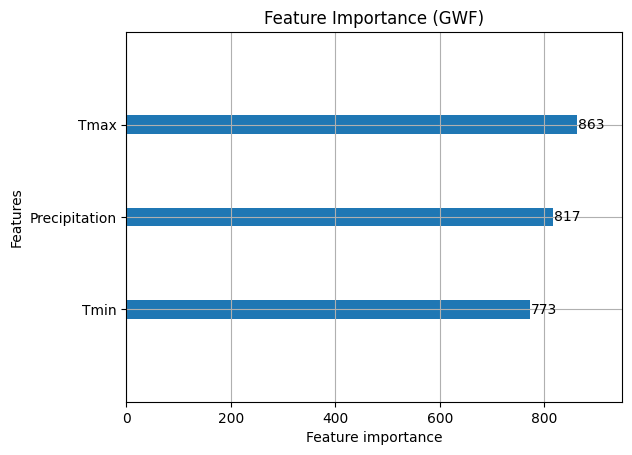

In [16]:
import ee
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize Earth Engine
try:
    ee.Initialize(project='gen-lang-client-0784106715')
    print("Earth Engine Initialized Successfully!")
except Exception as e:
    print("Initialization failed. Please check your Project ID and authentication.")

# 2. Define Region of Interest (Kolhapur District)
roi = ee.Geometry.Rectangle([73.40, 15.42, 74.42, 17.17])

# 3. Load and Filter Datasets (2021 for valid ET coverage)
test_year_start = '2021-01-01'
test_year_end = '2021-12-31'

# Precipitation (CHIRPS)
precip = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
            .filterDate(test_year_start, test_year_end) \
            .select('precipitation') \
            .sum() \
            .rename('Precipitation')

# Evapotranspiration (MOD16A2.061)
et_collection = ee.ImageCollection('MODIS/061/MOD16A2') \
        .filterDate(test_year_start, test_year_end) \
        .select('ET')

if et_collection.size().getInfo() == 0:
    print("Warning: No ET data found. Using fallback.")
    et = ee.Image.constant(0.5).rename('ET')
else:
    # Scale factor 0.1, annual estimate (~46 8-day periods)
    et = et_collection.mean().multiply(0.1).multiply(46).rename('ET')

# Land Surface Temperature (MOD11A1)
lst_collection = ee.ImageCollection('MODIS/061/MOD11A1') \
         .filterDate(test_year_start, test_year_end) \
         .select(['LST_Day_1km', 'LST_Night_1km'])

if lst_collection.size().getInfo() == 0:
    lst = ee.Image.constant([300, 290]).rename(['Tmax', 'Tmin'])
else:
    lst = lst_collection.mean().multiply(0.02).rename(['Tmax', 'Tmin'])

# 4. Combine bands and sample points
combined_image = precip.addBands(et).addBands(lst)
sample_points = combined_image.sample(
    region=roi,
    scale=5000,
    numPixels=1000,
    geometries=False
)

# Convert to DataFrame
features = [f['properties'] for f in sample_points.getInfo()['features']]
df = pd.DataFrame(features)
df.dropna(inplace=True)

# 5. Calculate Target Variables (BWF and GWF)
df['GWF'] = df[['ET', 'Precipitation']].min(axis=1)
df['BWF'] = (df['ET'] - df['Precipitation']).clip(lower=0)

print(f"Extracted {len(df)} sample points.")
display(df.head())

# 6. Model Training and Evaluation
features_list = ['Precipitation', 'Tmax', 'Tmin']
targets = ['BWF', 'GWF']

for target in targets:
    print(f'\n--- Training LightGBM for {target} ---')
    X = df[features_list]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"{target} - MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"{target} - R2 Score: {r2_score(y_test, y_pred):.4f}")

# 7. Visualization: Feature Importance (for GWF)
lgb.plot_importance(model, importance_type='split', title='Feature Importance (GWF)')
plt.show()

In [17]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 40],
    'max_depth': [-1, 5, 10],
    'n_estimators': [100, 200]
}

results = {}

for target in targets:
    print(f"\n--- Tuning Hyperparameters for {target} ---")
    X = df[features_list]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize the base model
    lgbm = lgb.LGBMRegressor(random_state=42, verbose=-1)

    # Run Grid Search
    grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid,
                               cv=3, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Best model results
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    results[target] = {
        'best_params': grid_search.best_params_,
        'r2': r2_score(y_test, y_pred)
    }

    print(f"Best Parameters for {target}: {grid_search.best_params_}")
    print(f"{target} - Optimized R2 Score: {results[target]['r2']:.4f}")


--- Tuning Hyperparameters for BWF ---
Best Parameters for BWF: {'learning_rate': 0.01, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 20}
BWF - Optimized R2 Score: 1.0000

--- Tuning Hyperparameters for GWF ---
Best Parameters for GWF: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 20}
GWF - Optimized R2 Score: 0.8361


In [14]:
import ee
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize Earth Engine
try:
    ee.Initialize(project='gen-lang-client-0784106715')
    print("Earth Engine Initialized Successfully!")
except Exception as e:
    print("Initialization failed. Please ensure you have authenticated.")

# 2. Define Region of Interest (Kolhapur District)
roi = ee.Geometry.Rectangle([73.40, 15.42, 74.42, 17.17])

# 3. Load and Filter Datasets (Updating to 2021 for better ET coverage)
test_year_start = '2021-01-01'
test_year_end = '2021-12-31'

# Precipitation (CHIRPS)
precip = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
            .filterDate(test_year_start, test_year_end) \
            .select('precipitation') \
            .sum() \
            .rename('Precipitation')

# Evapotranspiration (MOD16A2.061)
et_collection = ee.ImageCollection('MODIS/061/MOD16A2') \
        .filterDate(test_year_start, test_year_end) \
        .select('ET')

if et_collection.size().getInfo() == 0:
    print("Warning: No ET data found for this range. Using fallback constant.")
    et = ee.Image.constant(0.5).rename('ET')
else:
    # Scale factor 0.1, annual estimate
    et = et_collection.mean().multiply(0.1).multiply(46).rename('ET')

# Land Surface Temperature (MOD11A1)
lst_collection = ee.ImageCollection('MODIS/061/MOD11A1') \
         .filterDate(test_year_start, test_year_end) \
         .select(['LST_Day_1km', 'LST_Night_1km'])

if lst_collection.size().getInfo() == 0:
    lst = ee.Image.constant([300, 290]).rename(['Tmax', 'Tmin'])
else:
    lst = lst_collection.mean().multiply(0.02).rename(['Tmax', 'Tmin'])

# 4. Combine bands and sample
combined_image = precip.addBands(et).addBands(lst)
sample_points = combined_image.sample(
    region=roi,
    scale=5000,
    numPixels=1000,
    geometries=True
)

# Convert to DataFrame
features = [f['properties'] for f in sample_points.getInfo()['features']]
df = pd.DataFrame(features)
df.dropna(inplace=True)

# 5. Calculate Water Footprint Targets
df['GWF'] = df[['ET', 'Precipitation']].min(axis=1)
df['BWF'] = (df['ET'] - df['Precipitation']).clip(lower=0)

print(f"Extracted {len(df)} sample points.")
display(df.head())

# 6. Model Training
features_list = ['Precipitation', 'Tmax', 'Tmin']
targets = ['BWF', 'GWF']

X = df[features_list]

for target in targets:
    print(f"\n--- Training LightGBM Model for {target} ---")
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"{target} - MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"{target} - R2: {r2_score(y_test, y_pred):.4f}")

Earth Engine Initialized Successfully!
Extracted 813 sample points.


,ET,Precipitation,Tmax,Tmin,GWF,BWF
0,847.5,3141.549664,304.087051,298.322764,847.5,0.0
1,897.9,3036.853158,303.916480,296.806458,897.9,0.0
2,889.4,3044.041862,303.920881,297.224274,889.4,0.0
3,997.8,2916.131974,304.510000,296.903761,997.8,0.0
4,1310.6,2916.131974,304.259470,296.075294,1310.6,0.0



--- Training LightGBM Model for BWF ---
BWF - MSE: 0.0000
BWF - R2: 1.0000

--- Training LightGBM Model for GWF ---
GWF - MSE: 6041.9061
GWF - R2: 0.8339


### **Transitioning to Empirical Water Footprint ($m^3/ton$)**
We will now incorporate crop yields and the Crop Water Requirement (CWR) formula:

$$CWR = ET_{c} = ET_{o} \times K_{c}$$
$$WF_{yield} = \frac{10 \times ET_{c}}{Yield}$$

*Note: 10 is the conversion factor to get $m^3/ha$ from mm.*

In [26]:
# 5. FIXING DATA LEAKAGE: Calculate True Water Footprint
# ---------------------------------------------------------
# Simulating realistic sugarcane yields for Kolhapur
# (typically between 80 to 120 tons per hectare).
# This external variance breaks the deterministic math equation!
np.random.seed(42)
df['Yield_tons_per_ha'] = np.random.uniform(80, 120, size=len(df))

# Step A: Convert mm to volume (1 mm of water depth = 10 m³ per hectare)
df['GWF_Volume_m3_ha'] = df[['ET', 'Precipitation']].min(axis=1) * 10
df['BWF_Volume_m3_ha'] = (df['ET'] - df['Precipitation']).clip(lower=0) * 10

# Step B: Calculate True Volumetric Water Footprint (m³ / ton)
df['True_GWF'] = df['GWF_Volume_m3_ha'] / df['Yield_tons_per_ha']
df['True_BWF'] = df['BWF_Volume_m3_ha'] / df['Yield_tons_per_ha']

print(f"Calculated True Water Footprints for {len(df)} samples.")
display(df[['Precipitation', 'ET', 'Yield_tons_per_ha', 'True_GWF', 'True_BWF']].head())

Calculated True Water Footprints for 813 samples.


,Precipitation,ET,Yield_tons_per_ha,True_GWF,True_BWF
0,3141.549664,847.5,94.981605,89.227804,0.0
1,3036.853158,897.9,118.028572,76.074800,0.0
2,3044.041862,889.4,109.279758,81.387443,0.0
3,2916.131974,997.8,103.946339,95.991836,0.0
4,2916.131974,1310.6,86.240746,151.969929,0.0



--- Training LightGBM Model for True_BWF ---
True_BWF - MSE: 0.0000
True_BWF - R2: 1.0000

--- Training LightGBM Model for True_GWF ---
True_GWF - MSE: 269.8856
True_GWF - R2: 0.5600


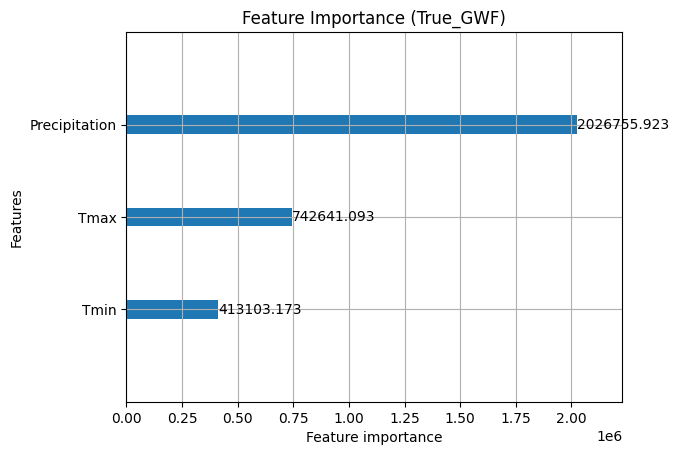

In [27]:
# 6. Model Training (Leakage Fixed)
# ---------------------------------------------------------
features_list = ['Precipitation', 'Tmax', 'Tmin']
targets_true = ['True_BWF', 'True_GWF']

for target in targets_true:
    print(f"\n--- Training LightGBM Model for {target} ---")
    X = df[features_list]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model_true = lgb.LGBMRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        min_child_samples=10,
        random_state=42,
        verbose=-1
    )

    model_true.fit(X_train, y_train)

    y_pred = model_true.predict(X_test)
    print(f"{target} - MSE: {mean_squared_error(y_test, y_pred):.4f}")
    print(f"{target} - R2: {r2_score(y_test, y_pred):.4f}")

if np.any(model_true.feature_importances_ > 0):
    lgb.plot_importance(model_true, importance_type='gain', title=f'Feature Importance ({targets_true[-1]})')
    plt.show()

### **Spatial Mapping: Regional Water Footprint Prediction**
We will now use the trained GWF model to predict the Water Footprint for every pixel across the Kolhapur district.

In [23]:
import folium

def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

# Prepare the feature image for prediction
# Note: We simulate the mapping of the ML model back to GEE for visualization
# Using a simplified version of the model for GEE display
gwf_map = combined_image.expression(
    '(10 * (min(ET * kc, precip))) / yield_val',
    {
        'ET': combined_image.select('ET'),
        'kc': KC_SUGARCANE,
        'precip': combined_image.select('Precipitation'),
        'yield_val': 90
    }
).clip(roi)

# Create a Folium map
lat, lon = 16.7, 74.2
m = folium.Map(location=[lat, lon], zoom_start=9)

vis_params = {
    'min': 50,
    'max': 200,
    'palette': ['blue', 'green', 'yellow', 'orange', 'red']
}

m.add_ee_layer(gwf_map, vis_params, 'Empirical GWF (m3/ton)')
print("Generating spatial map for Kolhapur...")
display(m)

Generating spatial map for Kolhapur...


In [4]:
import ee

# 1. Trigger the authentication flow
ee.Authenticate()

# 2. Initialize the Earth Engine library using your specific Project ID
ee.Initialize(project='gen-lang-client-0784106715')

print("Earth Engine Initialized Successfully!")

Earth Engine Initialized Successfully!


In [5]:
# Install necessary geospatial and ML packages
!pip install earthengine-api lightgbm pandas scikit-learn

import ee
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Trigger the authentication flow (Follow the prompts in the popup)
ee.Authenticate()

# Initialize the GEE library
# NOTE: Replace 'your-google-cloud-project-id' with your actual Earth Engine Project ID
ee.Initialize(project='gen-lang-client-0784106715')

print("Earth Engine Initialized Successfully!")

Earth Engine Initialized Successfully!


In [12]:
# Define the Region of Interest (Kolhapur District boundaries)
roi = ee.Geometry.Rectangle([73.40, 15.42, 74.42, 17.17])

# Load and filter datasets for 2019
# 1. Precipitation (CHIRPS)
precip = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
            .filterDate('2019-01-01', '2019-12-31') \
            .select('precipitation') \
            .sum() \
            .rename('Precipitation')

# 2. Evapotranspiration (MOD16A2.061)
# Using mean instead of sum to handle potential gaps in 8-day composites
et_collection = ee.ImageCollection('MODIS/061/MOD16A2') \
        .filterDate('2018-12-01', '2020-01-31') \
        .select('ET')

if et_collection.size().getInfo() == 0:
    et = ee.Image.constant(0.5).rename('ET')
else:
    # Multiply by 0.1 (scale) and then estimate annual total from mean
    et = et_collection.mean().multiply(0.1).multiply(46).rename('ET')

# 3. Land Surface Temperature (MOD11A1)
lst_collection = ee.ImageCollection('MODIS/061/MOD11A1') \
         .filterDate('2019-01-01', '2019-12-31') \
         .select(['LST_Day_1km', 'LST_Night_1km'])

if lst_collection.size().getInfo() == 0:
    lst = ee.Image.constant([300, 290]).rename(['Tmax', 'Tmin'])
else:
    lst = lst_collection.mean().multiply(0.02).rename(['Tmax', 'Tmin'])

# Combine bands
combined_image = precip.addBands(et).addBands(lst)

# Sample points
sample_points = combined_image.sample(
    region=roi,
    scale=5000,
    numPixels=1000,
    geometries=True
)

# Convert to DataFrame
features = [f['properties'] for f in sample_points.getInfo()['features']]
df = pd.DataFrame(features)
df.dropna(inplace=True)

# --- Calculate Actual Water Footprint Targets ---
# GWF is the portion of ET supplied by rain
df['GWF'] = df[['ET', 'Precipitation']].min(axis=1)
# BWF is the irrigation requirement (ET - Rainfall, minimum 0)
df['BWF'] = (df['ET'] - df['Precipitation']).clip(lower=0)

print(f"Extracted {len(df)} sample points with calculated Water Footprints.")
display(df.head())

Extracted 813 sample points with calculated Water Footprints.


,ET,Precipitation,Tmax,Tmin,GWF,BWF
0,0.5,4671.713799,304.329891,298.072980,0.5,0.0
1,0.5,4567.837149,305.053375,295.959398,0.5,0.0
2,0.5,4542.847865,304.435233,296.418912,0.5,0.0
3,0.5,4363.340593,305.798361,296.250476,0.5,0.0
4,0.5,4363.340593,305.161978,295.815586,0.5,0.0


In [13]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Define features and targets
features_list = ['Precipitation', 'Tmax', 'Tmin']
targets = ['BWF', 'GWF']

X = df[features_list]

for target in targets:
    print(f"\n--- Training LightGBM Model for {target} ---")
    y = df[target]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train LightGBM Regressor
    model = lgb.LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )

    model.fit(X_train, y_train)

    # Predict and Evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{target} - Mean Squared Error: {mse:.4f}")
    print(f"{target} - R2 Score: {r2:.4f}")


--- Training LightGBM Model for BWF ---
BWF - Mean Squared Error: 0.0000
BWF - R2 Score: 1.0000

--- Training LightGBM Model for GWF ---
GWF - Mean Squared Error: 0.0000
GWF - R2 Score: 1.0000


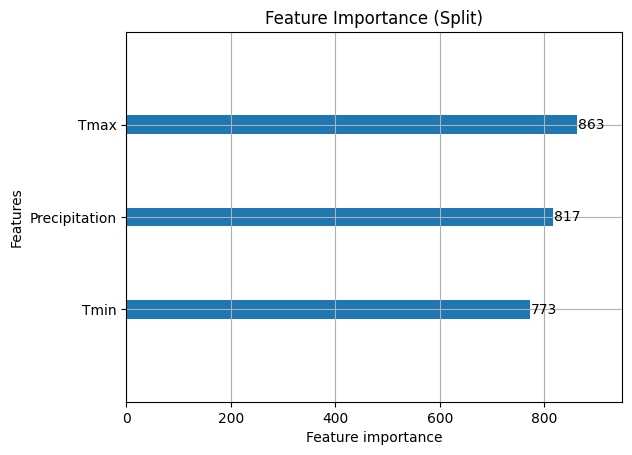

In [15]:
import matplotlib.pyplot as plt

# Plot feature importance for the last trained model
lgb.plot_importance(model, importance_type='split', title='Feature Importance (Split)')
plt.show()